In [1]:
import os
import gc
import ast
import copy
import time
import random
import numpy as np
import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as torchdata

from Model.MENDR.MENDREncoder import MENDRAutoEncoder, WaveletEncoderDecoder
from Model.MENDR.MENDRContextualizer import MENDRContextualizer
from Model.MENDR.MENDRTrainer import MENDRTrainer
from Model.MENDR.mAtt.optimizer import MixOptimizer
from Model.MENDR.mAtt.spd import SPDTangentSpace

from dataset import WaveletFinetuningDataset
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from torchmetrics.classification import BinaryAccuracy, MulticlassAccuracy
import xgboost as xgb

In [2]:
# Load Dataset
print("*" * 50)
train_dataset = WaveletFinetuningDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
print("Dataset Loaded. Length of Train Dataset: ", len(train_dataset))
eval_dataset = WaveletFinetuningDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(eval_dataset))

**************************************************
Loading 2130 folders


100%|██████████| 2130/2130 [02:07<00:00, 16.70it/s]


Dataset Loaded. Length of Train Dataset:  44854
Loading 253 folders


100%|██████████| 253/253 [00:12<00:00, 20.78it/s]

Dataset Loaded. Length of Validation Dataset:  5101


In [3]:
### Seed ###
torch.cuda.empty_cache()
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
## CUDNN ##
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [4]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
train_loader = DataLoader(train_dataset, batch_size=256, num_workers=2, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=256, num_workers=2, shuffle=False)
print(len(train_loader), len(eval_loader))

def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1), keepdim=True)
	std = torch.std(x, dim=(0, 1), keepdim=True)
	x = (x - mean) / std
	return x

176 20


In [5]:
### Model ###
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = MENDRAutoEncoder(device=device)
contextualizer = MENDRContextualizer(device=device)

for param in encoder.parameters():
    param.requires_grad = False

for param in contextualizer.parameters():
    param.requires_grad = False

encoder.load_state_dict(torch.load("checkpoint/batch_size256_40epochs/encoder_weights.pth"))
contextualizer.load_state_dict(torch.load("checkpoint/batch_size256_40epochs/contextualizer_weights.pth"))

<All keys matched successfully>

In [6]:
pbar = tqdm.trange(len(train_loader), desc="Training")
data_iterator = iter(train_loader)
outputs = []
output_labels = []

tangent_space = SPDTangentSpace(19, device)
flatten = nn.Flatten().to(device)

for iteration in pbar:
    data = next(data_iterator)

    for key, value in data.items():
        if isinstance(value, torch.Tensor):
            # Perform batch normalization across channels 
            data[key] = _std_norm(value.float().to(device))

    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        encoder_outputs = encoder(data['graph'], inputs)
        wavelet_manifold_output, epoched_shape = contextualizer.WaveletContextualizer(encoder_outputs)
        combined_r2e_output, combined_manifold_output = contextualizer.CombinedContextualizer(wavelet_manifold_output, epoched_shape)

        output_labels.append(data['graph'].y)
        embed_cat = [combined_r2e_output]
        for band, embedding in wavelet_manifold_output.items():
            embedding_r2e = tangent_space(embedding).view(epoched_shape[0], epoched_shape[1], -1)
            embedding_r2e = flatten(embedding_r2e)
            embed_cat.append(embedding_r2e)
        embed_cat = torch.cat(embed_cat, dim=1)
        outputs.append(embed_cat)

Training: 100%|██████████| 176/176 [12:24<00:00,  4.23s/it]


In [7]:
output_train_all = torch.cat(outputs, dim=0).cpu().numpy()
print(output_train_all.shape)

(44854, 4560)


In [8]:
output_labels_all = torch.cat(output_labels, dim=0).cpu().numpy()
print(output_labels_all.shape)

(44854,)


In [71]:
rf_clf = RandomForestClassifier(max_depth=8, random_state=42, n_estimators=200)

In [72]:
rf_clf.fit(output_train_all, output_labels_all)

RandomForestClassifier(max_depth=8, random_state=42)

In [73]:
y_pred = rf_clf.predict(output_train_all)

In [74]:
balanced_acc = balanced_accuracy_score(output_labels_all, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.3f}")

Balanced Accuracy: 0.689


In [9]:
pbar = tqdm.trange(len(eval_loader), desc="Validation")
data_iterator = iter(eval_loader)
outputs = []
output_labels = []

tangent_space = SPDTangentSpace(19, device)
flatten = nn.Flatten().to(device)

for iteration in pbar:
    data = next(data_iterator)
    for key, value in data.items():
        if isinstance(value, torch.Tensor):
            # Perform batch normalization across channels 
            data[key] = _std_norm(value.float().to(device))

    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]
    inputs = dict(zip(BANDS, relevant_bands))
    with torch.no_grad():
        encoder_outputs = encoder(data['graph'], inputs)
        wavelet_manifold_output, epoched_shape = contextualizer.WaveletContextualizer(encoder_outputs)
        combined_r2e_output, combined_manifold_output = contextualizer.CombinedContextualizer(wavelet_manifold_output, epoched_shape)
        
        output_labels.append(data['graph'].y)
        embed_cat = [combined_r2e_output]
        for band, embedding in wavelet_manifold_output.items():
            embedding_r2e = tangent_space(embedding).view(epoched_shape[0], epoched_shape[1], -1)
            embedding_r2e = flatten(embedding_r2e)
            embed_cat.append(embedding_r2e)
        embed_cat = torch.cat(embed_cat, dim=1)
        outputs.append(embed_cat)



Validation: 100%|██████████| 20/20 [02:24<00:00,  7.23s/it]


In [10]:
output_test_all = torch.cat(outputs, dim=0).cpu().numpy()
print(output_test_all.shape)

(5101, 4560)


In [11]:
output_labels_test_all = torch.cat(output_labels, dim=0).cpu().numpy()
print(output_labels_test_all.shape)

(5101,)


In [78]:
y_pred_test= rf_clf.predict(output_test_all)

In [79]:
balanced_acc = balanced_accuracy_score(output_labels_test_all, y_pred_test)
print(f"Balanced Accuracy Validation: {balanced_acc:.3f}")

Balanced Accuracy Validation: 0.657


In [80]:
xgb_classifier = xgb.XGBClassifier(
    tree_method="hist",
    eval_metric='error',
    objective="binary:logistic",
    n_estimators=1024,
    max_depth=6,
)

In [81]:
xgb_classifier.fit(output_train_all, output_labels_all, eval_set=[(output_test_all, output_labels_test_all)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1024, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [85]:
y_pred_test= xgb_classifier.predict(output_test_all)
balanced_acc = balanced_accuracy_score(output_labels_test_all, y_pred_test)
print(f"Balanced Accuracy Validation: {balanced_acc:.3f}")

Balanced Accuracy Validation: 0.656


In [86]:
from ConfigSpace import Configuration, ConfigurationSpace
from smac import HyperparameterOptimizationFacade, Scenario

In [86]:
def train(config: Configuration, seed: int = 0) -> float:
    classifier = xgb.XGBClassifier(tree_method="hist",
                                    val_metric='error',
                                    objective="binary:logistic",
                                    n_estimators=config['n_estimators'],
                                    max_depth=config['max_depth'])
    xgb_classifier.fit(output_train_all, output_labels_all, eval_set=[(output_test_all, output_labels_test_all)], verbose=False)
    balanced_acc = balanced_accuracy_score(output_labels_test_all, y_pred_test)
    return 1 - balanced_acc

In [ ]:
configspace = ConfigurationSpace({"n_estimators": (64, 1024), "max_depth": (1, 15)})

# Scenario object specifying the optimization environment
scenario = Scenario(configspace, deterministic=True, n_trials=10)

# Use SMAC to find the best configuration/hyperparameters
smac = HyperparameterOptimizationFacade(scenario, train)
incumbent = smac.optimize()

In [12]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding, MDS
from sklearn.metrics import accuracy_score

/home/hice1/mchen439/scratch/miniconda3/envs/Wavelet/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
reducer1 = PCA(n_components=760)
#reducer2 = MDS()
#reducer2 = SpectralEmbedding()
#reducer2 = LocallyLinearEmbedding(method='ltsa', eigen_solver='dense', n_components=2)
#reduer2 = Isomap()
reducer2 = umap.UMAP(n_components=2)

In [14]:
output_train_all_pca = reducer1.fit_transform(output_train_all)
print(f"Explained Var ratio:", reducer1.explained_variance_ratio_.sum())

Explained Var ratio: 0.8430941


In [15]:
output_test_all_pca = reducer1.fit_transform(output_test_all)
print(f"Explained Var ratio:", reducer1.explained_variance_ratio_.sum())

Explained Var ratio: 0.8732462


In [17]:
reducer2.fit(output_train_all_pca, output_labels_all, jobs=-1)

UMAP(tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

Text(0.5, 1.0, 'UMAP projection')

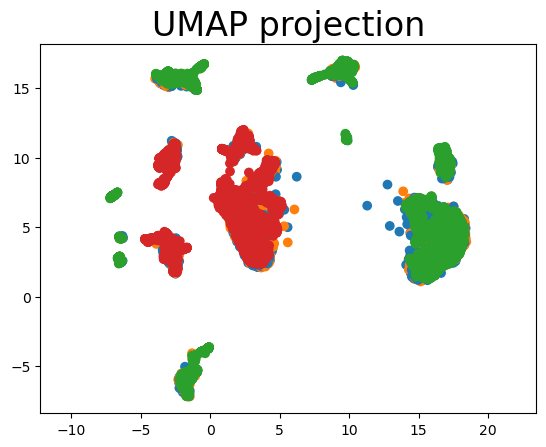

In [19]:
embedding = reducer2.transform(output_test_all_pca)
embedding2 = reducer2.transform(output_train_all_pca)

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in output_labels_test_all])

ax.scatter(
    embedding2[:, 0],
    embedding2[:, 1],
    c=[sns.color_palette()[x + 2] for x in output_labels_all])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection', fontsize=24)